# Reto: Auditoría energética exprés de un edificio de oficinas

### Aplica lo que aprendiste en EDA y Machine Learning — tú solo(a), con Copilot como apoyo

---

## El encargo

Un edificio de oficinas les entrega **45 días de mediciones horarias** (archivo `reto_edificio_oficinas.csv`, en la misma carpeta que este notebook) y les hace un encargo corto: una primera auditoría energética exprés, con datos y con un modelo, para presentar en una reunión de una hora.

Ya no hay nadie guiándolos celda por celda. Aquí ustedes deciden **qué hacer, en qué orden, y cuánto código escribir a mano vs. pedirle a Copilot**. Este notebook solo les da la estructura (las preguntas que hay que responder y el tiempo sugerido para cada una) — el análisis lo construyen ustedes.

## Datos disponibles

El archivo `reto_edificio_oficinas.csv` tiene una fila por hora, con estas columnas:

| Columna | Qué representa |
|---|---|
| `fecha_hora` | Momento de la medición |
| `energia_kwh` | Energía consumida en esa hora |
| `demanda_kw` | Potencia demandada en ese instante |
| `temperatura_c` | Temperatura ambiente |
| `ocupacion` | Número de personas en el edificio |
| `tipo_dia` | "Laboral" o "Fin de semana" |
| `estado_hvac` | Si el sistema de climatización estaba "Encendido" o "Apagado" |

> No asuman que estos datos llegan limpios. Como en la clase de EDA, es su responsabilidad auditarlos antes de sacar cualquier conclusión.

## Las cuatro preguntas que deben responder

1. **¿Podemos confiar en estos datos?** (calidad)
2. **¿Cuándo y por qué consume energía este edificio?** (patrones y relaciones)
3. **¿Se puede predecir el consumo a partir de ocupación y temperatura?** (modelo)
4. **¿Qué le recomendarían al administrador del edificio?** (conclusión)

## Cómo van a trabajar

- Pueden apoyarse en **GitHub Copilot** para escribir código, tal como practicaron en la clase anterior: formulen el prompt con nombres exactos de columnas y el resultado que esperan, y **validen** lo que les devuelva antes de darlo por bueno.
- Al final de este notebook hay un **banco de pistas opcional** (prompts de referencia), por si algún equipo se atasca. Intenten resolver primero sin mirarlo.
- Este notebook trae únicamente **celdas de tarea** (con instrucciones) y celdas de código **vacías** para que ustedes trabajen. No hay respuestas escondidas.

## Cronómetro sugerido (60 minutos)

| Tarea | Minutos |
|---|---|
| 1. Cargar y explorar los datos | 8 |
| 2. Auditoría rápida de calidad | 7 |
| 3. Limpieza mínima necesaria | 8 |
| 4. Patrones de consumo (mínimo 2 gráficos) | 12 |
| 5. Modelo de predicción de consumo | 15 |
| 6. Conclusión ejecutiva | 10 |

## Entregables (lo que deben tener listo al final)

- [ ] Una tabla de auditoría de calidad, con al menos completitud y validez revisadas.
- [ ] Una versión limpia de los datos, con las decisiones de limpieza justificadas en una línea de texto.
- [ ] Al menos **dos visualizaciones** que respondan la pregunta 2.
- [ ] Un modelo entrenado y evaluado (con una métrica de error) que responda la pregunta 3.
- [ ] Una conclusión ejecutiva de máximo 6 líneas, con al menos una recomendación concreta.

## Tarea 0 · Preparar el entorno (ya resuelta)

Esta celda sí viene dada, para que no pierdan tiempo del reto en pasos administrativos. Ejecútenla y empiecen a trabajar desde la Tarea 1.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")

df = pd.read_csv("reto_edificio_oficinas.csv", parse_dates=["fecha_hora"])
print("Filas cargadas:", len(df))
df.head()

Filas cargadas: 1083


,fecha_hora,energia_kwh,demanda_kw,temperatura_c,ocupacion,tipo_dia,estado_hvac
0,2026-04-01 00:00:00,5.42,5.64,20.20,3,Laboral,Apagado
1,2026-04-01 01:00:00,6.45,6.57,16.98,6,Laboral,Apagado
2,2026-04-01 02:00:00,9.91,9.84,17.18,4,Laboral,Apagado
3,2026-04-01 03:00:00,8.24,9.17,17.49,3,Laboral,Apagado
4,2026-04-01 04:00:00,4.96,5.42,16.19,0,Laboral,Apagado


## Tarea 1 · Exploración inicial — 8 minutos

Antes de nada, confirmen que entienden la estructura básica de la tabla.

**Qué deben lograr en esta celda:**

- Ver las dimensiones de la tabla (filas y columnas).
- Confirmar el periodo de tiempo que cubren los datos.
- Revisar el tipo de dato de cada columna (`.info()`), prestando atención a `fecha_hora` — ¿quedó como fecha o como texto?

💡 *Si necesitan ayuda con el código, pídanselo a Copilot describiendo exactamente qué necesitan ver, con el nombre de la variable `df`.*

In [2]:
# Tarea 1 · Exploración inicial
print("Dimensiones (filas, columnas):", df.shape)
print("Periodo:", df["fecha_hora"].min(), "→", df["fecha_hora"].max())
print("Días cubiertos:", (df["fecha_hora"].max() - df["fecha_hora"].min()).days + 1)
print("Horas esperadas en ese periodo:", len(pd.date_range(df["fecha_hora"].min(), df["fecha_hora"].max(), freq="h")))
print()
df.info()
df.describe().T

Dimensiones (filas, columnas): (1083, 7)
Periodo: 2026-04-01 00:00:00 → 2026-05-15 23:00:00
Días cubiertos: 45
Horas esperadas en ese periodo: 1080

<class 'pandas.DataFrame'>
RangeIndex: 1083 entries, 0 to 1082
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   fecha_hora     1083 non-null   datetime64[us]
 1   energia_kwh    1075 non-null   float64       
 2   demanda_kw     1083 non-null   float64       
 3   temperatura_c  1077 non-null   float64       
 4   ocupacion      1083 non-null   int64         
 5   tipo_dia       1083 non-null   str           
 6   estado_hvac    1079 non-null   str           
dtypes: datetime64[us](1), float64(3), int64(1), str(2)
memory usage: 59.4 KB


,count,mean,min,25%,50%,75%,max,std
fecha_hora,1083,2026-04-23 11:30:24.930748,2026-04-01 00:00:00,2026-04-12 06:30:00,2026-04-23 11:00:00,2026-05-04 17:30:00,2026-05-15 23:00:00,NaN
energia_kwh,"1,075.00",10.90,-5.00,7.16,9.28,14.34,55.82,5.32
demanda_kw,"1,083.00",11.16,1.43,7.29,9.51,14.57,52.41,5.39
temperatura_c,"1,077.00",20.97,14.15,18.31,21.07,23.58,28.03,3.05
ocupacion,"1,083.00",35.93,0.00,3.00,6.00,64.50,150.00,46.17


## Tarea 2 · Auditoría rápida de calidad — 7 minutos

Recuerden las cuatro dimensiones de calidad que vimos en la clase de EDA: **completitud, unicidad, validez y consistencia**. No tienen que hacer una auditoría exhaustiva — es un reto corto — pero sí deben poder responder, con evidencia (una tabla o un número), estas tres preguntas:

1. ¿Qué columnas tienen valores faltantes, y cuántos?
2. ¿Hay marcas de tiempo (`fecha_hora`) duplicadas?
3. ¿Los valores de `energia_kwh` son todos físicamente posibles (no negativos)? ¿Y la columna `estado_hvac` tiene categorías escritas de forma consistente?

In [3]:
# Tarea 2 · Auditoría rápida de calidad (completitud, unicidad, validez, consistencia)
auditoria = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "faltantes": df.isna().sum(),
    "% faltantes": (df.isna().mean() * 100).round(2),
    "valores_unicos": df.nunique(),
})
display(auditoria)

n_dup = df["fecha_hora"].duplicated().sum()
filas_dup_identicas = df.duplicated().sum()
n_neg = (df["energia_kwh"] < 0).sum()
print(f"Unicidad  → fecha_hora duplicadas: {n_dup} (de ellas, filas 100% idénticas: {filas_dup_identicas})")
print(f"Validez   → energia_kwh negativa: {n_neg} filas; valores: {df.loc[df.energia_kwh < 0, 'energia_kwh'].tolist()}")
print("Consistencia → categorías de estado_hvac (repr muestra espacios ocultos):")
print(df["estado_hvac"].map(repr).value_counts())
print("\nCategorías de tipo_dia:", df["tipo_dia"].unique().tolist())

# Chequeo extra: ¿hay picos sospechosos? (regla IQR sobre energía)
q1, q3 = df.energia_kwh.quantile([.25, .75]); lim = q3 + 3 * (q3 - q1)
df[df.energia_kwh > lim]

,tipo,faltantes,% faltantes,valores_unicos
fecha_hora,datetime64[us],0,0.00,1080
energia_kwh,float64,8,0.74,1071
demanda_kw,float64,0,0.00,1080
temperatura_c,float64,6,0.55,1074
ocupacion,int64,0,0.00,134
tipo_dia,str,0,0.00,2
estado_hvac,str,4,0.37,3


Unicidad  → fecha_hora duplicadas: 3 (de ellas, filas 100% idénticas: 3)
Validez   → energia_kwh negativa: 2 filas; valores: [-5.0, -5.0]
Consistencia → categorías de estado_hvac (repr muestra espacios ocultos):
estado_hvac
'Apagado'       647
'Encendido'     427
'encendido '      5
nan               4
Name: count, dtype: int64

Categorías de tipo_dia: ['Laboral', 'Fin de semana']


,fecha_hora,energia_kwh,demanda_kw,temperatura_c,ocupacion,tipo_dia,estado_hvac
465,2026-04-20 07:00:00,55.82,52.41,17.87,52,Laboral,Encendido


## Tarea 3 · Limpieza mínima necesaria — 8 minutos

Con lo que encontraron en la Tarea 2, hagan **solo** la limpieza que sea necesaria — no hace falta repetir todo el proceso extenso de la clase de EDA. Como mínimo:

- Eliminen filas con `fecha_hora` duplicada (si las hay).
- Decidan qué hacer con los valores de `energia_kwh` físicamente imposibles (¿los convierten en faltante? ¿los interpolan?).
- Unifiquen la escritura de `estado_hvac` si encontraron inconsistencias.

Guarden el resultado en una nueva variable, por ejemplo `df_limpio`, para no perder el DataFrame original por si necesitan volver a consultarlo.

> Escriban, en una celda de texto (Markdown) después de su código, **una línea explicando cada decisión de limpieza que tomaron y por qué**. Esa justificación es parte del entregable.

In [4]:
# Tarea 3 · Limpieza mínima necesaria
df_limpio = (df.drop_duplicates(subset="fecha_hora", keep="first")
               .sort_values("fecha_hora")
               .set_index("fecha_hora"))

# 1) Energía negativa = físicamente imposible → NaN y luego interpolación temporal
df_limpio.loc[df_limpio["energia_kwh"] < 0, "energia_kwh"] = np.nan
df_limpio["energia_kwh"] = df_limpio["energia_kwh"].interpolate(method="time")
df_limpio["temperatura_c"] = df_limpio["temperatura_c"].interpolate(method="time")

# 2) Unificar texto de estado_hvac ("encendido " → "Encendido")
df_limpio["estado_hvac"] = df_limpio["estado_hvac"].str.strip().str.title()

# 3) Columnas de apoyo y relleno de HVAC faltante con la regla observada en los datos
df_limpio["hora"] = df_limpio.index.hour
df_limpio["en_horario"] = (df_limpio["tipo_dia"] == "Laboral") & df_limpio["hora"].between(7, 19)
df_limpio["estado_hvac"] = df_limpio["estado_hvac"].fillna(
    df_limpio["en_horario"].map({True: "Encendido", False: "Apagado"}))

# Validación de la limpieza
assert df_limpio.index.is_unique and (df_limpio.energia_kwh >= 0).all()
print("Filas:", len(df_limpio), "| faltantes restantes:", int(df_limpio.isna().sum().sum()))
print(df_limpio["estado_hvac"].value_counts())
print("Regla HVAC = horario laboral 07–19 h se cumple en", f"{((df_limpio.estado_hvac=='Encendido')==df_limpio.en_horario).mean():.1%}", "de las horas")

Filas: 1080 | faltantes restantes: 0
estado_hvac
Apagado      647
Encendido    433
Name: count, dtype: int64
Regla HVAC = horario laboral 07–19 h se cumple en 99.6% de las horas


**Decisiones de limpieza:**
- **3 duplicados de `fecha_hora`** (filas idénticas) → se eliminan: la serie debe tener una sola medición por hora (quedan 1.080 = 45 días × 24 h).
- **2 valores de −5 kWh** → imposibles físicamente; se pasan a NaN y se interpolan en el tiempo junto con los **8 faltantes** de energía y **6** de temperatura (son huecos aislados de una hora).
- **`estado_hvac`**: "encendido " (5 casos) se unifica a "Encendido"; los **4 faltantes** se rellenan con la regla que cumplen los datos (encendido solo en días laborales de 07 a 19 h).
- **El pico de 55,8 kWh** (lunes 20-abr, 07:00) **no se elimina**: la demanda (52,4 kW) lo confirma y coincide con el arranque tras el fin de semana; se reporta como hallazgo.

## Tarea 4 · Patrones de consumo — 12 minutos

Con `df_limpio`, respondan la pregunta 2 del encargo: **¿cuándo y por qué consume energía este edificio?**

Construyan **al menos dos** visualizaciones (elijan las que mejor respondan la pregunta; no hace falta hacer las cinco). Algunas ideas, no obligatorias:

- Un perfil horario de consumo promedio (como el de la clase de EDA).
- Una comparación de consumo entre días laborales y fines de semana.
- Una relación entre `ocupacion` o `temperatura_c` y `energia_kwh` (dispersión o correlación).
- Un mapa de calor de consumo por hora y tipo de día.

Después de cada gráfico, escriban **una frase de interpretación**: ¿qué les dice ese gráfico sobre el edificio?

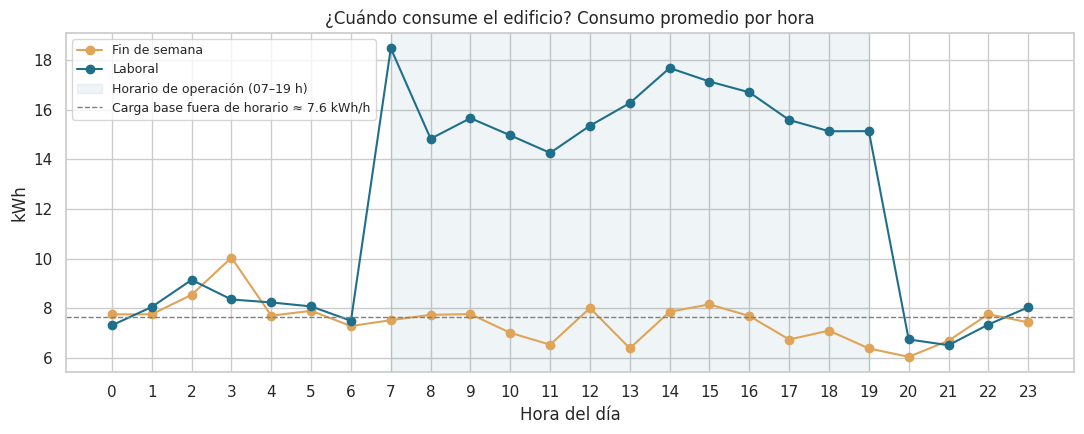

Consumo fuera de horario: 42.1% del total | carga en operación: 15.9 kWh/h


In [5]:
# Visualización 1 · Perfil horario promedio: laboral vs fin de semana
perfil = df_limpio.groupby(["hora", "tipo_dia"])["energia_kwh"].mean().unstack()
ax = perfil.plot(figsize=(11, 4.5), marker="o", color={"Laboral": "#1f6f8b", "Fin de semana": "#e0a458"})
ax.axvspan(7, 19, color="#1f6f8b", alpha=.07, label="Horario de operación (07–19 h)")
base = df_limpio.loc[~df_limpio.en_horario, "energia_kwh"].mean()
ax.axhline(base, ls="--", color="gray", lw=1, label=f"Carga base fuera de horario ≈ {base:.1f} kWh/h")
ax.set(title="¿Cuándo consume el edificio? Consumo promedio por hora", xlabel="Hora del día", ylabel="kWh", xticks=range(24))
ax.legend(loc="upper left", fontsize=9); plt.tight_layout(); plt.show()

pct_fuera = df_limpio.loc[~df_limpio.en_horario, "energia_kwh"].sum() / df_limpio["energia_kwh"].sum()
print(f"Consumo fuera de horario: {pct_fuera:.1%} del total | carga en operación: {df_limpio.loc[df_limpio.en_horario,'energia_kwh'].mean():.1f} kWh/h")

*Interpretación:* el consumo se duplica en horario laboral (≈16 kWh/h de 07 a 19 h), pero el edificio nunca "se apaga": mantiene una carga base de ≈7,6 kWh/h de noche y los fines de semana, que suma **~42 % de toda la energía** aun con 3–4 personas dentro.

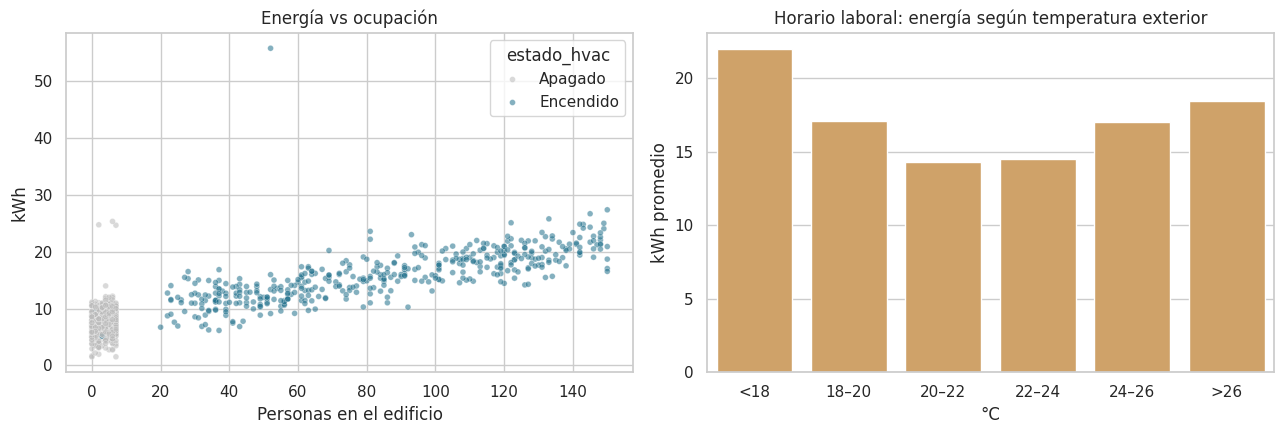

               energia_kwh  ocupacion  temperatura_c
energia_kwh           1.00       0.86           0.36
ocupacion             0.86       1.00           0.46
temperatura_c         0.36       0.46           1.00


In [6]:
# Visualización 2 · ¿Por qué consume? Ocupación y temperatura
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.scatterplot(data=df_limpio, x="ocupacion", y="energia_kwh", hue="estado_hvac", alpha=.55, s=18,
                palette={"Encendido": "#1f6f8b", "Apagado": "#bbbbbb"}, ax=axes[0])
axes[0].set(title="Energía vs ocupación", xlabel="Personas en el edificio", ylabel="kWh")

op = df_limpio[df_limpio.en_horario].copy()
op["rango_temp"] = pd.cut(op.temperatura_c, [0, 18, 20, 22, 24, 26, 40],
                          labels=["<18", "18–20", "20–22", "22–24", "24–26", ">26"])
sns.barplot(data=op, x="rango_temp", y="energia_kwh", color="#e0a458", errorbar=None, ax=axes[1])
axes[1].set(title="Horario laboral: energía según temperatura exterior", xlabel="°C", ylabel="kWh promedio")
plt.tight_layout(); plt.show()
print(df_limpio[["energia_kwh", "ocupacion", "temperatura_c"]].corr().round(2))

*Interpretación:* la **ocupación** es el motor principal del consumo (correlación 0,86); la temperatura actúa en forma de **"U"**: el consumo es mínimo entre 20 y 24 °C y sube cuando hace frío (calefacción/arranque) o calor (>24 °C, refrigeración), por eso su correlación lineal parece débil (0,36). (La barra "<18 °C" incluye el pico de arranque del lunes 20-abr.)

## Tarea 5 · Modelo de predicción de consumo — 15 minutos

Ahora respondan la pregunta 3: **¿se puede predecir el consumo a partir de ocupación y temperatura?**

Sigan el mismo patrón que en la clase de Machine Learning:

1. Elijan las variables de entrada (como mínimo `ocupacion` y `temperatura_c`; pueden agregar más si quieren, como la hora del día).
2. Dividan los datos en entrenamiento y prueba, **respetando el orden cronológico** (no aleatorio).
3. Entrenen un modelo de regresión (el que prefieran: regresión lineal o bosque aleatorio).
4. Evalúen con al menos una métrica (error promedio o R²) sobre el conjunto de prueba.
5. Si usaron un bosque aleatorio, revisen qué variable resultó más importante.

💡 *Si usan una variable de texto como `tipo_dia` o `estado_hvac` como entrada, recuerden que primero hay que codificarla (como hicimos con `tarifa` en la clase anterior).*

In [7]:
# Tarea 5.1 · Variables de entrada
df_modelo = df_limpio.copy()
df_modelo = pd.get_dummies(df_modelo, columns=["tipo_dia"], prefix="dia", dtype=int)
df_modelo["en_horario"] = df_modelo["en_horario"].astype(int)
# Distancia a la zona de confort (22 °C) solo cuando el HVAC trabaja → captura la "U" de la temperatura
df_modelo["desv_confort"] = (df_modelo["temperatura_c"] - 22).abs() * df_modelo["en_horario"]

features_min = ["ocupacion", "temperatura_c"]                                   # lo que pide el reto
features_ext = ["ocupacion", "temperatura_c", "en_horario", "desv_confort"]    # versión mejorada
df_modelo[features_ext + ["dia_Laboral", "energia_kwh"]].head()

,ocupacion,temperatura_c,en_horario,desv_confort,dia_Laboral,energia_kwh
fecha_hora,,,,,,
2026-04-01 00:00:00,3,20.20,0,0.00,1,5.42
2026-04-01 01:00:00,6,16.98,0,0.00,1,6.45
2026-04-01 02:00:00,4,17.18,0,0.00,1,9.91
2026-04-01 03:00:00,3,17.49,0,0.00,1,8.24
2026-04-01 04:00:00,0,16.19,0,0.00,1,4.96


In [8]:
# Tarea 5.2 · División cronológica 80/20 (pasado → entrena, futuro → prueba)
corte = int(len(df_modelo) * 0.8)
train, test = df_modelo.iloc[:corte], df_modelo.iloc[corte:]
y_train, y_test = train["energia_kwh"], test["energia_kwh"]
print(f"Entrenamiento: {len(train)} h  ({train.index.min():%d-%b} → {train.index.max():%d-%b})")
print(f"Prueba:        {len(test)} h  ({test.index.min():%d-%b} → {test.index.max():%d-%b})")
assert train.index.max() < test.index.min() and len(train) + len(test) == len(df_modelo)

Entrenamiento: 864 h  (01-Apr → 06-May)
Prueba:        216 h  (07-May → 15-May)


In [9]:
# Tarea 5.3 · Entrenar y evaluar (MAE y R² sobre prueba)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

filas, modelos = [], {}
mae_ingenuo = mean_absolute_error(y_test, np.full(len(y_test), y_train.mean()))
filas.append(["Referencia: predecir siempre el promedio", "-", mae_ingenuo, 0.0])
for nombre_set, feats in [("ocupación + temperatura", features_min), ("extendido", features_ext)]:
    for nombre, modelo in [("Regresión lineal", LinearRegression()),
                           ("Random Forest", RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42))]:
        modelo.fit(train[feats], y_train)
        pred = modelo.predict(test[feats])
        modelos[(nombre, nombre_set)] = (modelo, feats, pred)
        filas.append([nombre, nombre_set, mean_absolute_error(y_test, pred), r2_score(y_test, pred)])

resultados = pd.DataFrame(filas, columns=["modelo", "variables", "MAE_kWh", "R2"])
display(resultados)
print(f"Consumo medio en prueba: {y_test.mean():.2f} kWh/h")

,modelo,variables,MAE_kWh,R2
0,Referencia: predecir siempre el promedio,-,4.23,0.00
1,Regresión lineal,ocupación + temperatura,1.74,0.79
2,Random Forest,ocupación + temperatura,1.69,0.76
3,Regresión lineal,extendido,1.60,0.80
4,Random Forest,extendido,1.66,0.79


Consumo medio en prueba: 10.90 kWh/h


### Tarea 5.4 · ¿Qué variable pesa más? y ¿qué tan bien sigue el modelo la realidad?

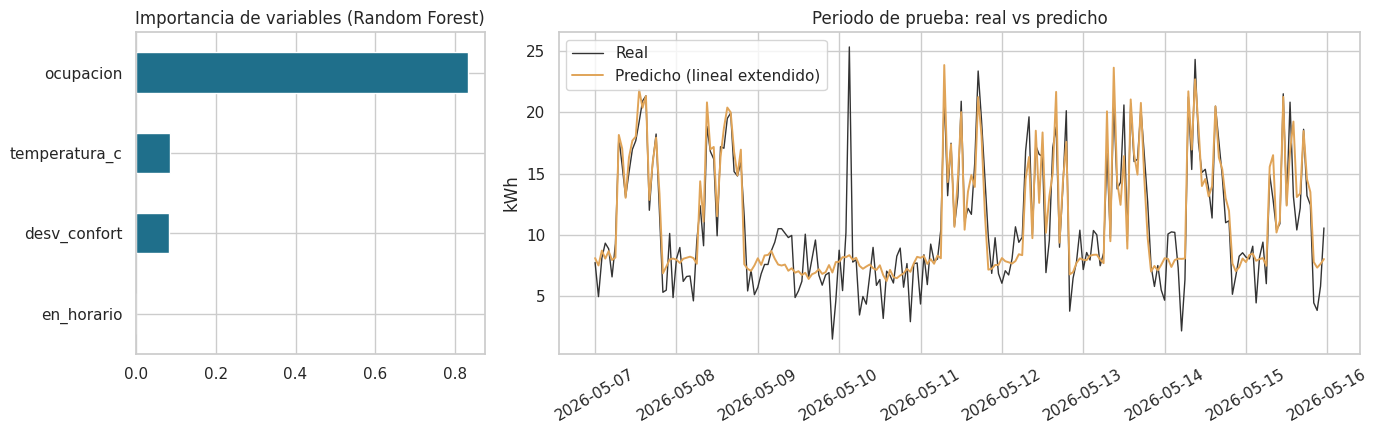

Coeficientes del modelo lineal extendido:
ocupacion        0.09
temperatura_c   -0.18
en_horario      -1.35
desv_confort     1.43
dtype: float64 
intercepto: 10.81


In [10]:
rf, feats_rf, _ = modelos[("Random Forest", "extendido")]
lr, feats_lr, pred_lr = modelos[("Regresión lineal", "extendido")]
imp = pd.Series(rf.feature_importances_, index=feats_rf).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={"width_ratios": [1, 2.3]})
imp.plot.barh(ax=axes[0], color="#1f6f8b"); axes[0].set(title="Importancia de variables (Random Forest)")
axes[1].plot(test.index, y_test, label="Real", color="#333", lw=1)
axes[1].plot(test.index, pred_lr, label="Predicho (lineal extendido)", color="#e0a458", lw=1.4)
axes[1].set(title="Periodo de prueba: real vs predicho", ylabel="kWh"); axes[1].legend()
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()
print("Coeficientes del modelo lineal extendido:")
print(pd.Series(lr.coef_, index=feats_lr).round(3), "\nintercepto:", round(lr.intercept_, 3))

**Lectura del modelo:** sí se puede predecir el consumo: con solo ocupación y temperatura el error medio es ≈1,7 kWh por hora (R² ≈ 0,79), la mitad del error de un pronóstico ingenuo. Añadir el horario y la distancia a la zona de confort (22 °C) baja el error a ≈1,6 kWh (R² ≈ 0,80). La regresión lineal empata o supera al Random Forest: la relación es sencilla y con 45 días el modelo simple generaliza mejor. La ocupación explica más del 80 % de la importancia.

## Tarea 6 · Conclusión ejecutiva — 10 minutos

Cierren el reto con una conclusión de **máximo 6 líneas**, dirigida al administrador del edificio (que no sabe de estadística ni de machine learning). Debe incluir, como mínimo:

- Un hecho respaldado por un número (por ejemplo, el error de su modelo, o el porcentaje de consumo fuera de horario).
- Una interpretación de ese hecho.
- **Una recomendación concreta y accionable.**
- Una limitación honesta de su análisis (por ejemplo: "solo 45 días de datos", "no incluye el clima de todas las estaciones", etc.).

Escriban su conclusión reemplazando el texto de la celda siguiente.

**Conclusión ejecutiva**
1. **Hecho:** el 42 % de la energía se consume fuera del horario laboral (noches y fines de semana), con apenas 3–4 personas en el edificio.
2. **Interpretación:** hay una carga base de ≈7,6 kWh cada hora que no depende de la ocupación (iluminación, equipos en espera, servidores, bombas).
3. **Modelo:** el consumo se predice con un error medio de ≈1,6 kWh/h (R² 0,80); la ocupación es el factor que más pesa, y la temperatura influye solo fuera de 20–24 °C.
4. **Recomendación:** programar apagado automático de iluminación y equipos a las 20:00 y fines de semana, y revisar qué queda encendido de noche; bajar la carga base un 30 % ahorraría ≈1.500 kWh cada 45 días (≈12.000 kWh/año). Escalonar el arranque de los lunes 07:00 evitaría picos como el de 52 kW.
5. **Limitación:** solo 45 días (abril–mayo), sin estaciones extremas ni medición por circuitos; el ahorro es una estimación a validar con submedición.

## Extra · Exportar resultados para el tablero web (HTML + CSS + JS)

Python hace el análisis; el tablero web solo **consume** este JSON. Así el dashboard siempre refleja el notebook.

In [11]:
import json
lr_ext, f_ext, pred_ext = modelos[("Regresión lineal", "extendido")]
salida = {
  "periodo": [str(df_limpio.index.min()), str(df_limpio.index.max())],
  "auditoria": {"filas_originales": len(df), "duplicados": int(n_dup), "negativos": int(n_neg),
                "faltantes": df.isna().sum().to_dict(), "hvac_categorias": df["estado_hvac"].map(repr).value_counts().to_dict()},
  "serie": {"t": df_limpio.index.strftime("%Y-%m-%d %H").tolist(),
            "e": df_limpio.energia_kwh.round(2).tolist(), "o": df_limpio.ocupacion.tolist(),
            "tc": df_limpio.temperatura_c.round(1).tolist(), "lab": (df_limpio.tipo_dia=="Laboral").astype(int).tolist()},
  "modelos": resultados.round(3).to_dict(orient="records"),
  "lineal": {"coef": dict(zip(f_ext, lr_ext.coef_.round(4))), "intercepto": round(lr_ext.intercept_, 4)},
  "importancia": dict(zip(feats_rf, rf.feature_importances_.round(4))),
  "prueba": {"t": test.index.strftime("%Y-%m-%d %H").tolist(), "real": y_test.round(2).tolist(), "pred": np.round(pred_ext, 2).tolist()},
}
with open("datos_dashboard.json", "w", encoding="utf-8") as f:
    json.dump(salida, f, ensure_ascii=False)
print("datos_dashboard.json exportado")

datos_dashboard.json exportado


---

## 🆘 Banco de pistas opcional — solo si su equipo se atasca

No lo lean antes de intentar cada tarea por su cuenta. Son prompts de referencia para Copilot, por si se quedan sin ideas de cómo formular la pregunta.

**Para la Tarea 1 (exploración):**
> Tengo un DataFrame `df` con una columna `fecha_hora`. Muéstrame sus dimensiones, el rango de fechas mínimo y máximo, y un resumen de tipos de dato con `.info()`.

**Para la Tarea 2 (calidad):**
> Tengo un DataFrame `df` con columnas `fecha_hora`, `energia_kwh`, `demanda_kw`, `temperatura_c`, `ocupacion`, `tipo_dia`, `estado_hvac`. Constrúyeme una tabla con el porcentaje de valores faltantes por columna, dime cuántas filas tienen `fecha_hora` duplicada, cuántas filas tienen `energia_kwh` negativa, y muéstrame el conteo de valores únicos de `estado_hvac`.

**Para la Tarea 3 (limpieza):**
> Tengo un DataFrame `df` con una columna de fecha `fecha_hora`, una columna numérica `energia_kwh` que no debería tener valores negativos, y una columna de texto `estado_hvac` con inconsistencias de mayúsculas y espacios. Escribe código en pandas que elimine duplicados por `fecha_hora`, convierta los valores negativos de `energia_kwh` en NaN y los rellene por interpolación temporal, y unifique el texto de `estado_hvac` quitando espacios y usando formato título. Guarda el resultado en `df_limpio`.

**Para la Tarea 4 (patrones):**
> Tengo un DataFrame `df_limpio` indexado o con una columna `fecha_hora`, con columnas `energia_kwh`, `ocupacion`, `temperatura_c` y `tipo_dia`. Grafica el consumo promedio de energía por hora del día, separando entre días "Laboral" y "Fin de semana", en el mismo gráfico con dos líneas.

**Para la Tarea 5 (modelo):**
> Tengo un DataFrame `df_limpio` ordenado cronológicamente por `fecha_hora`, con columnas `energia_kwh`, `ocupacion`, `temperatura_c` y `tipo_dia` (texto). Escribe código en Python con scikit-learn que codifique `tipo_dia` con `pd.get_dummies`, divida los datos en 80% entrenamiento y 20% prueba de forma cronológica (sin mezclar aleatoriamente), entrene un `RandomForestRegressor` para predecir `energia_kwh` a partir de `ocupacion`, `temperatura_c` y las columnas codificadas de `tipo_dia`, y calcule el error absoluto promedio y el R² sobre el conjunto de prueba.